自编码器与PCA降维对比

**作业要求：**
- 使用Iris数据集，从4维降到2维
- 实现PCA和自编码器两种降维方法
- 对比两种方法的差别
- 尝试不使用激活函数的效果

---

## 1. 导入库和数据准备

In [1]:
# 导入需要的库
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import paddle
import paddle.nn as nn
import os
import warnings
warnings.filterwarnings('ignore')

# GPU设置
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
try:
    paddle.set_device('gpu')
    test = paddle.to_tensor([1.0])
    del test
    print("Using GPU")
except:
    paddle.set_device('cpu')
    print("Using CPU")

# 设置随机种子
np.random.seed(42)
paddle.seed(42)

# 绘图设置
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

c:\Users\A208-7\.conda\envs\fealpy_pip_env\Lib\site-packages\paddle\utils\cpp_extension\extension_utils.py:711: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)


Using CPU


In [2]:
# 加载Iris数据
iris = load_iris()
X = iris.data
y = iris.target

print(f"Data shape: {X.shape}")
print(f"Classes: {iris.target_names}")

# 数据标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"Standardized data range: [{X_scaled.min():.2f}, {X_scaled.max():.2f}]")

Data shape: (150, 4)
Classes: ['setosa' 'versicolor' 'virginica']
Standardized data range: [-2.43, 3.09]


## 2. PCA降维

In [3]:
# PCA降维
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"PCA explained variance: {pca.explained_variance_ratio_.sum():.2%}")
print(f"PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"PC2: {pca.explained_variance_ratio_[1]:.2%}")

PCA explained variance: 95.81%
PC1: 72.96%
PC2: 22.85%


## 3. 自编码器降维（带激活函数）

In [4]:
# 定义自编码器
class Autoencoder(nn.Layer):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(4, 2),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(2, 4),
            nn.ReLU()
        )
    
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded, encoded

# 转换数据
X_tensor = paddle.to_tensor(X_scaled, dtype='float32')

# 初始化模型
model_ae = Autoencoder()
optimizer_ae = paddle.optimizer.Adam(learning_rate=0.0, parameters=model_ae.parameters())
loss_fn = nn.MSELoss()

print("Autoencoder model initialized")

Autoencoder model initialized


In [5]:
# 训练自编码器
epochs = 200
loss_history = []

for epoch in range(epochs):
    model_ae.train()
    recon, encoded = model_ae(X_tensor)
    loss = loss_fn(recon, X_tensor)
    loss_history.append(loss.item())
    
    loss.backward()
    optimizer_ae.step()
    optimizer_ae.clear_grad()
    
    if (epoch + 1) % 5 == 0 or epoch < 3:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.6f}")

# 获取降维结果
model_ae.eval()
with paddle.no_grad():
    _, X_ae = model_ae(X_tensor)
    X_ae = X_ae.numpy()

print(f"Final loss: {loss_history[-1]:.6f}")

Epoch 1/200, Loss: 1.141814
Epoch 2/200, Loss: 1.141814
Epoch 3/200, Loss: 1.141814
Epoch 5/200, Loss: 1.141814
Epoch 10/200, Loss: 1.141814
Epoch 15/200, Loss: 1.141814
Epoch 20/200, Loss: 1.141814
Epoch 25/200, Loss: 1.141814
Epoch 30/200, Loss: 1.141814
Epoch 35/200, Loss: 1.141814
Epoch 40/200, Loss: 1.141814
Epoch 45/200, Loss: 1.141814
Epoch 50/200, Loss: 1.141814
Epoch 55/200, Loss: 1.141814
Epoch 60/200, Loss: 1.141814
Epoch 65/200, Loss: 1.141814
Epoch 70/200, Loss: 1.141814
Epoch 75/200, Loss: 1.141814
Epoch 80/200, Loss: 1.141814
Epoch 85/200, Loss: 1.141814
Epoch 90/200, Loss: 1.141814
Epoch 95/200, Loss: 1.141814
Epoch 100/200, Loss: 1.141814
Epoch 105/200, Loss: 1.141814
Epoch 110/200, Loss: 1.141814
Epoch 115/200, Loss: 1.141814
Epoch 120/200, Loss: 1.141814
Epoch 125/200, Loss: 1.141814
Epoch 130/200, Loss: 1.141814
Epoch 135/200, Loss: 1.141814
Epoch 140/200, Loss: 1.141814
Epoch 145/200, Loss: 1.141814
Epoch 150/200, Loss: 1.141814
Epoch 155/200, Loss: 1.141814
Epoch 

## 4. 线性自编码器（无激活函数）

In [6]:
# 定义线性自编码器（无激活函数）
class LinearAutoencoder(nn.Layer):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Linear(4, 2)
        self.decoder = nn.Linear(2, 4)
    
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded, encoded

# 初始化并训练
model_linear = LinearAutoencoder()
optimizer_linear = paddle.optimizer.Adam(learning_rate=0.01, parameters=model_linear.parameters())
loss_history_linear = []

for epoch in range(epochs):
    model_linear.train()
    recon, encoded = model_linear(X_tensor)
    loss = loss_fn(recon, X_tensor)
    loss_history_linear.append(loss.item())
    
    loss.backward()
    optimizer_linear.step()
    optimizer_linear.clear_grad()
    
    if (epoch + 1) % 5 == 0 or epoch < 3:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.6f}")

# 获取降维结果
model_linear.eval()
with paddle.no_grad():
    _, X_linear_ae = model_linear(X_tensor)
    X_linear_ae = X_linear_ae.numpy()

print(f"Final loss: {loss_history_linear[-1]:.6f}")

Epoch 1/200, Loss: 2.178117
Epoch 2/200, Loss: 2.098778
Epoch 3/200, Loss: 2.023679
Epoch 5/200, Loss: 1.885958
Epoch 10/200, Loss: 1.592469
Epoch 15/200, Loss: 1.364420
Epoch 20/200, Loss: 1.195171
Epoch 25/200, Loss: 1.070716
Epoch 30/200, Loss: 0.977017
Epoch 35/200, Loss: 0.904630
Epoch 40/200, Loss: 0.846435
Epoch 45/200, Loss: 0.796830
Epoch 50/200, Loss: 0.752447
Epoch 55/200, Loss: 0.711428
Epoch 60/200, Loss: 0.672547
Epoch 65/200, Loss: 0.634992
Epoch 70/200, Loss: 0.597947
Epoch 75/200, Loss: 0.560302
Epoch 80/200, Loss: 0.520643
Epoch 85/200, Loss: 0.477393
Epoch 90/200, Loss: 0.429279
Epoch 95/200, Loss: 0.376035
Epoch 100/200, Loss: 0.319077
Epoch 105/200, Loss: 0.261605
Epoch 110/200, Loss: 0.207657
Epoch 115/200, Loss: 0.160686
Epoch 120/200, Loss: 0.122838
Epoch 125/200, Loss: 0.094812
Epoch 130/200, Loss: 0.075778
Epoch 135/200, Loss: 0.063808
Epoch 140/200, Loss: 0.056677
Epoch 145/200, Loss: 0.052506
Epoch 150/200, Loss: 0.050033
Epoch 155/200, Loss: 0.048535
Epoch 

## 5. 结果评估

In [7]:
# 计算类别分离度
sil_pca = silhouette_score(X_pca, y)
sil_ae = silhouette_score(X_ae, y)
sil_linear = silhouette_score(X_linear_ae, y)

print("Silhouette Scores:")
print(f"PCA: {sil_pca:.4f}")
print(f"Autoencoder (ReLU): {sil_ae:.4f}")
print(f"Linear Autoencoder: {sil_linear:.4f}")

# 重构误差
with paddle.no_grad():
    recon_ae, _ = model_ae(X_tensor)
    recon_linear, _ = model_linear(X_tensor)
    mse_ae = ((X_tensor - recon_ae) ** 2).mean().item()
    mse_linear = ((X_tensor - recon_linear) ** 2).mean().item()

print(f"\nReconstruction Error:")
print(f"Autoencoder (ReLU): {mse_ae:.6f}")
print(f"Linear Autoencoder: {mse_linear:.6f}")

Silhouette Scores:
PCA: 0.4014
Autoencoder (ReLU): -0.0497
Linear Autoencoder: 0.2910

Reconstruction Error:
Autoencoder (ReLU): 1.141814
Linear Autoencoder: 0.044757


## 6. 可视化

Saved: comparison_result.png


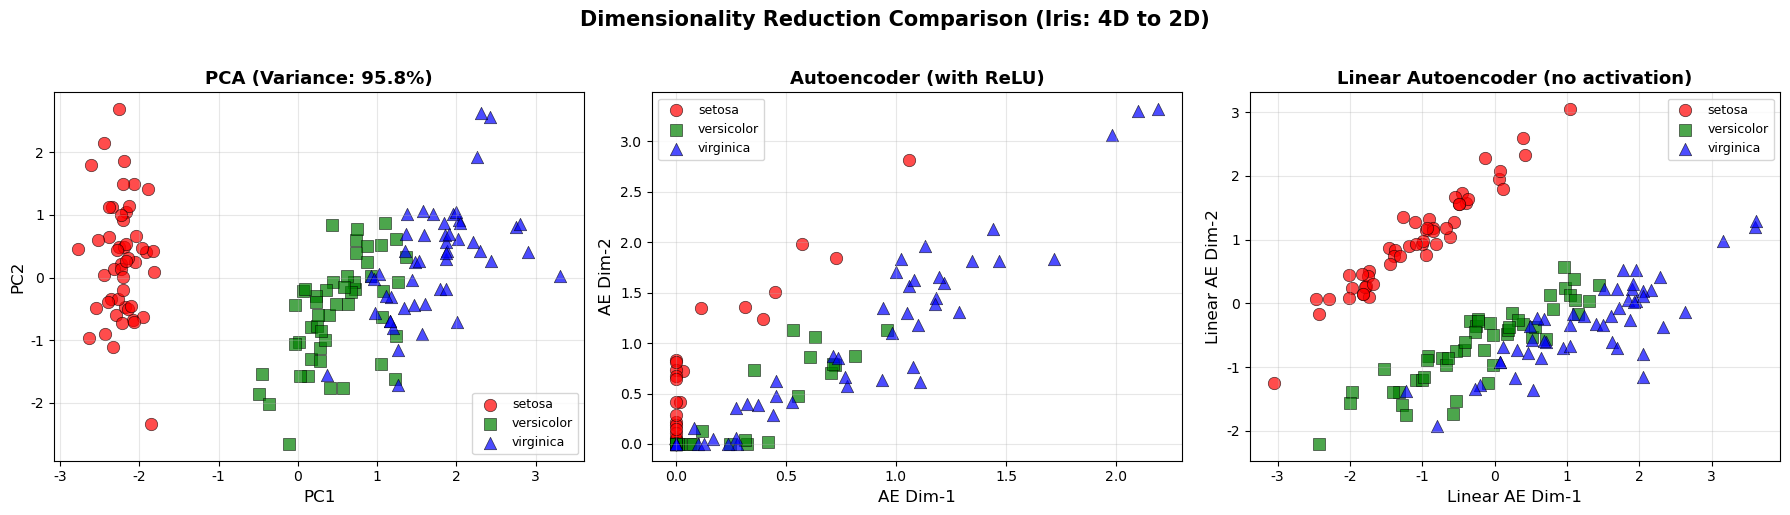

In [8]:
# 绘图参数
colors = ['red', 'green', 'blue']
markers = ['o', 's', '^']

# 创建对比图
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# PCA
for i, label in enumerate(np.unique(y)):
    mask = y == label
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], 
                   c=colors[i], marker=markers[i], 
                   label=iris.target_names[label], 
                   alpha=0.7, s=80, edgecolors='black', linewidth=0.5)
axes[0].set_title(f'PCA (Variance: {pca.explained_variance_ratio_.sum():.1%})', fontsize=13, fontweight='bold')
axes[0].set_xlabel('PC1', fontsize=12)
axes[0].set_ylabel('PC2', fontsize=12)
axes[0].legend(loc='best', fontsize=9)
axes[0].grid(True, alpha=0.3)

# Autoencoder (ReLU)
for i, label in enumerate(np.unique(y)):
    mask = y == label
    axes[1].scatter(X_ae[mask, 0], X_ae[mask, 1], 
                   c=colors[i], marker=markers[i], 
                   label=iris.target_names[label], 
                   alpha=0.7, s=80, edgecolors='black', linewidth=0.5)
axes[1].set_title('Autoencoder (with ReLU)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('AE Dim-1', fontsize=12)
axes[1].set_ylabel('AE Dim-2', fontsize=12)
axes[1].legend(loc='best', fontsize=9)
axes[1].grid(True, alpha=0.3)

# Linear Autoencoder
for i, label in enumerate(np.unique(y)):
    mask = y == label
    axes[2].scatter(X_linear_ae[mask, 0], X_linear_ae[mask, 1], 
                   c=colors[i], marker=markers[i], 
                   label=iris.target_names[label], 
                   alpha=0.7, s=80, edgecolors='black', linewidth=0.5)
axes[2].set_title('Linear Autoencoder (no activation)', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Linear AE Dim-1', fontsize=12)
axes[2].set_ylabel('Linear AE Dim-2', fontsize=12)
axes[2].legend(loc='best', fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.suptitle('Dimensionality Reduction Comparison (Iris: 4D to 2D)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('comparison_result.png', dpi=300, bbox_inches='tight')
print("Saved: comparison_result.png")
plt.show()